# Jadco Real Estate: XGBoost Market Pricing Model

This notebook constructs a Walk-Forward Backtesting pipeline to forecast building-level rent growth using internal lease data, concessions, and macroeconomic indicators (CMHC & CPI).

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 1. Internal Data Engineering

Here we load the primary Jadco datasets: `Lease History`, `Asking History`, and `Concessions`.

### The 'Lease-Up' Flag
We explicitly flag properties that are in their **'Lease-Up' phase**. A building in 'Lease-Up' is a brand new development that is entering the market for the first time. 
Because these buildings are brand new, they are exempt from strict rent control (such as the TAL's Clause F in Quebec) for their first 5 years. This allows landlords to implement much more aggressive rent hikes during renewals compared to older, established buildings that are capped by the government. 

Flagging this phase allows our model to mathematically anticipate these highly aggressive rent increases without having to memorize the literal name of the building!

### 2.1 Feature Engineering: Regulation and Absorption

To ensure the model adapts to varying market conditions, two key features are engineered:
- **Is_Ontario**: A binary flag to separate buildings under Ontario LTB guidelines versus Quebec TAL guidelines. This explicitly trains the model on differing rent control dynamics.
- **Effective_DOM**: A proxy for Days on Market (Absorption) calculated as the difference between the signature date and the availability date (`sSignDate - sAvailable`). Negative values represent high-demand pre-leasing, while positive values indicate stagnant vacancies.

In [130]:
data_dir = "data/"
lease_df = pd.read_csv(data_dir + "equinoxe_lease_history.csv")
lease_df.columns = lease_df.columns.str.strip()
asking_df = pd.read_csv(data_dir + "equinoxe_asking_history.csv")
asking_df.columns = asking_df.columns.str.strip()

# 1. Process Concessions
conc_df = pd.read_csv(data_dir + 'equinoxe_concessions.csv')
conc_df.columns = conc_df.columns.str.strip()
conc_df['sDateFrom'] = pd.to_datetime(conc_df['sDateFrom'])
conc_df['sAmount'] = conc_df['sAmount'].fillna(0)

conc_sorted = conc_df.sort_values('sDateFrom')
conc_dummies = pd.get_dummies(conc_sorted['sChargeCode'], prefix='Conc')
conc_processed = pd.concat([conc_sorted[['hUnit', 'sDateFrom']], conc_dummies], axis=1)

# Get max for flags, sum for dollar amounts
conc_amt = conc_sorted.groupby(['hUnit', 'sDateFrom'])['sAmount'].sum().reset_index()
conc_processed = conc_processed.groupby(['hUnit', 'sDateFrom']).max().reset_index()
conc_processed = pd.merge(conc_processed, conc_amt, on=['hUnit', 'sDateFrom'])
conc_processed = conc_processed.sort_values('sDateFrom')

# 2. Merge Concessions onto Leases
lease_df['sLeaseFrom_dt'] = pd.to_datetime(lease_df['sLeaseFrom'])
lease_sorted = lease_df.sort_values('sLeaseFrom_dt')

lease_df = pd.merge_asof(
    lease_sorted,
    conc_processed,
    by='hUnit',
    left_on='sLeaseFrom_dt',
    right_on='sDateFrom',
    direction='backward',
    tolerance=pd.Timedelta('365D')
)

concession_cols = [c for c in lease_df.columns if c.startswith('Conc_')]
lease_df[concession_cols] = lease_df[concession_cols].fillna(0).astype(int)
lease_df['sAmount'] = lease_df['sAmount'].fillna(0)

# 3. Flag 'Lease-Up' Strategy Buildings
brand_new_buildings = ['Le Carlyle', 'The Met', 'Westpark']

def is_lease_up(row):
    b = str(row['sBuilding']).strip()
    p = str(row['sPropCode']).strip()
    
    # Explicitly flag the new developments (exempt from TAL Clause F)
    if b in brand_new_buildings:
        return 1
    elif b == 'Saint-Elzear' and p == 'stelz3':
        return 1
    else:
        return 0  # Established buildings (Daniel-Johnson, Levesque, stelz1/2)

lease_df['Is_LeaseUp'] = lease_df.apply(is_lease_up, axis=1)
lease_df['Is_Ontario'] = lease_df['sState'].apply(lambda x: 1 if str(x).strip() == 'Ontario' else 0)
lease_df['sSignDate'] = pd.to_datetime(lease_df['sSignDate'], errors='coerce')
lease_df['sAvailable'] = pd.to_datetime(lease_df['sAvailable'], errors='coerce')
lease_df['Effective_DOM'] = (lease_df['sSignDate'] - lease_df['sAvailable']).dt.days
# Fill missing DOM with 0 as a neutral baseline
lease_df['Effective_DOM'] = lease_df['Effective_DOM'].fillna(0)

# 4. Clean up columns and parse dates
keep_cols = ['Is_LeaseUp', 'Is_Ontario', 'Effective_DOM', 'hUnit', 'sBuilding', 'sCity', 'sState', 'sTermSeq', 'sRent', 'sRentEffective', 'sBeds', 'sBaths', 'sSqft', 'sUnitType', 'sRenewal', 'sLeaseFrom', 'sTermMonths', 'sAmount'] + concession_cols
lease_df = lease_df[keep_cols].copy()

lease_df['sLeaseFrom'] = pd.to_datetime(lease_df['sLeaseFrom'])
lease_df['LeaseMonth'] = lease_df['sLeaseFrom'].dt.month.astype(str)
lease_df['MergeMonth'] = lease_df['sLeaseFrom'].dt.to_period('M').astype(str)

print(f"Base Lease Data Prepared: {lease_df.shape}")

Base Lease Data Prepared: (4302, 28)


## 2. Target Variable & Market Gaps

We sort the dataframe chronologically to calculate the **Annualized Rent Growth** between sequential leases in the same unit. We also merge the `Asking Rent` from exactly 12 months prior to calculate Market Velocity.

In [131]:
# 1. Calculate Previous Rent & Previous Concessions
lease_df = lease_df.sort_values(by=['hUnit', 'sTermSeq'])
lease_df['Previous_sRentEffective'] = lease_df.groupby('hUnit')['sRentEffective'].shift(1)
lease_df['Previous_sAmount'] = lease_df.groupby('hUnit')['sAmount'].shift(1)
lease_df['Previous_sLeaseFrom'] = lease_df.groupby('hUnit')['sLeaseFrom'].shift(1)

lease_df['Previous_Concession_Ratio'] = lease_df['Previous_sAmount'].abs() / (lease_df['Previous_sRentEffective'] * 12)
lease_df['Previous_Concession_Ratio'] = lease_df['Previous_Concession_Ratio'].fillna(0)

for col in concession_cols:
    lease_df[f'Previous_{col}'] = lease_df.groupby('hUnit')[col].shift(1)

# Drop first term sequences (we can't calculate growth if there is no previous rent)
model_df = lease_df.dropna(subset=['Previous_sRentEffective']).copy()
for col in concession_cols:
    model_df[f'Previous_{col}'] = model_df[f'Previous_{col}'].fillna(0).astype(int)

# 2. Target Variable: Annualized Growth Percentage
model_df['gap_years'] = (model_df['sLeaseFrom'] - model_df['Previous_sLeaseFrom']).dt.days / 365.25
model_df = model_df[model_df['gap_years'] >= 0.1].copy() # Filter mathematically unstable short leases
model_df['growth_pct'] = ((model_df['sRentEffective'] / model_df['Previous_sRentEffective']) ** (1 / model_df['gap_years']) - 1) * 100

# 3. Market Gap & Velocity (Using Asking Rents)
asking_df = asking_df[['hUnit', 'sMonth', 'sAskingRent']].copy()
asking_df['sMonth_dt'] = pd.to_datetime(asking_df['sMonth'] + '-01')
model_df['sLeaseFrom_dt'] = pd.to_datetime(model_df['MergeMonth'] + '-01')
model_df['sLeaseFrom_dt_minus_12m'] = model_df['sLeaseFrom_dt'] - pd.DateOffset(months=12)

asking_sorted = asking_df.sort_values('sMonth_dt')
model_sorted = model_df.sort_values('sLeaseFrom_dt')

# Current asking rent vs previous lease (Loss to Lease)
merged_df = pd.merge_asof(
    model_sorted, 
    asking_sorted, 
    by='hUnit', 
    left_on='sLeaseFrom_dt', 
    right_on='sMonth_dt', 
    direction='backward'
)

# Trailing 12-month asking rent (Velocity)
merged_df = pd.merge_asof(
    merged_df.sort_values('sLeaseFrom_dt_minus_12m'), 
    asking_sorted, 
    by='hUnit', 
    left_on='sLeaseFrom_dt_minus_12m', 
    right_on='sMonth_dt', 
    direction='backward',
    suffixes=('', '_12m_ago')
)

merged_df = merged_df.sort_values(['hUnit', 'sTermSeq'])
merged_df['Market_Gap'] = merged_df['sAskingRent'] - merged_df['Previous_sRentEffective']
merged_df['Market_Gap'] = merged_df['Market_Gap'].fillna(0)
merged_df['Market_Velocity'] = (merged_df['sAskingRent'] - merged_df['sAskingRent_12m_ago']) / merged_df['sAskingRent_12m_ago']
merged_df['Market_Velocity'] = merged_df['Market_Velocity'].fillna(0) 

print(f"Target Variable Engineered. Valid leases: {len(merged_df)}")

Target Variable Engineered. Valid leases: 3241


## 3. Macroeconomic Data (CMHC & CPI)

We merge external datasets to give the model a broader understanding of the real estate landscape (Vacancy Rates, Average Regional Rents, and Inflation).

### 3.1 Macroeconomic Data Ingestion

External indicators are loaded to capture broad market trends. Renamed, clarified datasets (such as `cpi_inflation.csv` and `cpi_building_construction.csv`) are joined to the pipeline by matching the Lease Year and Month.

In [132]:
# 1. CMHC Data Merge
cmhc_df = pd.read_csv(data_dir + "external_data/cmhc_consolidated.csv")
cmhc_df['Date_dt'] = pd.to_datetime(cmhc_df['Date'] + '-01')
cmhc_sorted = cmhc_df.sort_values('Date_dt')

cma_mapping = {'Mont-Royal': 'Montreal', 'Laval': 'Montreal', 'Pointe-Claire': 'Montreal', 'Ottawa': 'Ottawa'}
merged_df['CMA'] = merged_df['sCity'].map(cma_mapping).fillna('Montreal')

unit_mapping = {0: 'Studio', 1: '1 Bedroom', 2: '2 Bedroom', 3: '3 Bedroom +'}
merged_df['Unit_Type_CMHC'] = merged_df['sBeds'].map(unit_mapping)

merged_df = merged_df.sort_values('sLeaseFrom_dt')
merged_df = pd.merge_asof(
    merged_df,
    cmhc_sorted,
    left_on='sLeaseFrom_dt',
    right_on='Date_dt',
    left_by=['CMA', 'Unit_Type_CMHC'],
    right_by=['City', 'Unit_Type'],
    direction='backward'
)

merged_df['Vacancy_Rate_Pct'] = merged_df.groupby(['CMA', 'Unit_Type_CMHC'])['Vacancy_Rate_Pct'].transform(lambda x: x.bfill().ffill())
merged_df['Average_Rent'] = merged_df.groupby(['CMA', 'Unit_Type_CMHC'])['Average_Rent'].transform(lambda x: x.bfill().ffill())
merged_df['Rent_YoY_Growth_Pct'] = merged_df.groupby(['CMA', 'Unit_Type_CMHC'])['Rent_YoY_Growth_Pct'].transform(lambda x: x.bfill().ffill())

merged_df['CMHC_Market_Premium'] = (merged_df['Previous_sRentEffective'] - merged_df['Average_Rent']) / merged_df['Average_Rent']
merged_df['CMHC_Market_Premium'] = merged_df['CMHC_Market_Premium'].fillna(0)

# 2. CPI Inflation Merge (18-Month Lag)
cpi_df = pd.read_csv(data_dir + 'external_data/cpi_inflation.csv')
cpi_df = cpi_df[cpi_df['Products and product groups'] == 'Shelter'].copy()
cpi_df['Date_dt'] = pd.to_datetime(cpi_df['REF_DATE'] + '-01')
cpi_df = cpi_df.sort_values('Date_dt')
cpi_df = cpi_df[['Date_dt', 'VALUE']].rename(columns={'VALUE': 'CPI_Index_Shelter'})

merged_df['LeaseFrom_Lagged_18m'] = merged_df['sLeaseFrom_dt'] - pd.DateOffset(months=18)
merged_df = merged_df.sort_values('LeaseFrom_Lagged_18m')

merged_df = pd.merge_asof(
    merged_df,
    cpi_df,
    left_on='LeaseFrom_Lagged_18m',
    right_on='Date_dt',
    direction='backward'
)
merged_df['CPI_Index_Shelter'] = merged_df['CPI_Index_Shelter'].bfill().ffill()

# Impute minor missing data
merged_df['sBaths'] = merged_df['sBaths'].fillna(merged_df['sBaths'].median())
merged_df['sSqft'] = merged_df['sSqft'].fillna(merged_df['sSqft'].median())
merged_df['sTermMonths'] = merged_df['sTermMonths'].fillna(12)

print("Macro Data Merged Successfully.")

Macro Data Merged Successfully.


## 4. Building-Level Aggregation

To strip out the extreme noise of individual human negotiations (outliers like +1200% or -65%), we aggregate the dataset into **Building-Level Monthly Averages**. This transforms the model from a micro-predictor into a macro-forecaster.

### 4.1 Building-Level Aggregation: Renewals vs Turnovers

To explicitly answer the business question, we separate the predictions into two streams:
- **Renewals (`sRenewal = 1`)**: Tenants staying in place (subject to stricter rent control).
- **Turnovers (`sRenewal = 0`)**: Vacated units re-leased at market rates.

By grouping our data by `[sBuilding, LeaseMonth, sRenewal]`, the XGBoost model will natively output two distinct rent growth predictions per building per month.

In [133]:
# 1. Drop extreme unit-level outliers first to avoid poisoning the averages
valid_mask = merged_df['growth_pct'].between(-25, 50)
clean_df = merged_df[valid_mask].copy()
clean_df['Lease_Year'] = clean_df['sLeaseFrom_dt'].dt.year

print(f"Original unit-level rows: {len(clean_df)}")

# 2. AGGREGATE TO BUILDING-MONTH LEVEL
bldg_df = clean_df.groupby(['sBuilding', 'Lease_Year', 'LeaseMonth', 'sRenewal']).agg(
    growth_pct=('growth_pct', 'mean'),
    CPI_Index_Shelter=('CPI_Index_Shelter', 'mean'),
    Is_LeaseUp=('Is_LeaseUp', 'max'),
    Is_Ontario=('Is_Ontario', 'max'),
    Effective_DOM=('Effective_DOM', 'mean'),
    Market_Gap=('Market_Gap', 'mean'),
    Market_Velocity=('Market_Velocity', 'mean'),
    Vacancy_Rate_Pct=('Vacancy_Rate_Pct', 'mean'),
    Rent_YoY_Growth_Pct=('Rent_YoY_Growth_Pct', 'mean'),
    CMHC_Market_Premium=('CMHC_Market_Premium', 'mean'),
    Previous_sRentEffective=('Previous_sRentEffective', 'mean'),
    Previous_Concession_Ratio=('Previous_Concession_Ratio', 'mean'),
    Lease_Count=('hUnit', 'count')
).reset_index()

# 3. Filter out noise (months where only 1 or 2 random leases were signed)
bldg_df = bldg_df[bldg_df['Lease_Count'] >= 3].copy()
print(f"Aggregated Building-Month rows: {len(bldg_df)}")

# We intentionally drop `sBuilding` to prevent the model from memorizing building names.
# This forces the model to rely on `Is_LeaseUp` and macro data, allowing it to predict future brand new buildings!
features = [
    'Lease_Year', 'LeaseMonth', 'sRenewal', 'CPI_Index_Shelter', 'Is_LeaseUp', 'Is_Ontario', 'Effective_DOM', 
    'Market_Gap', 'Market_Velocity', 'Vacancy_Rate_Pct', 
    'Rent_YoY_Growth_Pct', 'CMHC_Market_Premium', 
    'Previous_sRentEffective', 'Previous_Concession_Ratio'
]

X = bldg_df[features].copy()
y = bldg_df['growth_pct']

# Dummy encoding for Seasonality
X = pd.get_dummies(X, columns=['LeaseMonth'], drop_first=True)
print(f"Final aggregated dataset ready. Shape: {X.shape}")

Original unit-level rows: 3241
Aggregated Building-Month rows: 461
Final aggregated dataset ready. Shape: (461, 24)


## 5. Walk-Forward Backtesting (XGBoost)

We simulate a real-world deployment by training the model strictly on past data (e.g., `< 2024`) and testing it exclusively on future unseen data (e.g., `== 2024`).

In [134]:
target_years = [2023, 2024, 2025]
results = []
models = {}

print("Starting Walk-Forward Backtesting for XGBoost...")

for year in target_years:
    print(f"\n--- Backtesting Year: {year} ---")
    
    # Train: All data strictly BEFORE the target year
    train_mask = X['Lease_Year'] < year
    # Test: All data strictly IN the target year
    test_mask = X['Lease_Year'] == year
    
    X_train = X[train_mask].drop(columns=['Lease_Year']).astype(float)
    y_train = y[train_mask]
    
    X_test = X[test_mask].drop(columns=['Lease_Year']).astype(float)
    y_test = y[test_mask]
    
    if len(X_test) == 0:
        print(f"Skipping {year} - No test data available.")
        continue
        
    print(f"Training on {len(X_train)} samples, Testing on {len(X_test)} samples.")
    
    # Initialize and train XGBoost
    # Reduced depth and estimators to prevent overfitting on the smaller aggregated dataset
    xgb_model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    )
    
    xgb_model.fit(X_train, y_train)
    models[year] = xgb_model
    
    # Predict
    preds = xgb_model.predict(X_test)
    
    # Evaluate Overall, Renewals, and Turnovers
    mae_overall = mean_absolute_error(y_test, preds)
    
    renewal_mask = X_test['sRenewal'] == 1
    turnover_mask = X_test['sRenewal'] == 0
    
    mae_renewal = mean_absolute_error(y_test[renewal_mask], preds[renewal_mask]) if renewal_mask.sum() > 0 else np.nan
    mae_turnover = mean_absolute_error(y_test[turnover_mask], preds[turnover_mask]) if turnover_mask.sum() > 0 else np.nan
    
    print(f"Results for {year}:")
    print(f"  -> Overall MAE  = {mae_overall:.4f}%")
    print(f"  -> Renewal MAE  = {mae_renewal:.4f}%")
    print(f"  -> Turnover MAE = {mae_turnover:.4f}%\n")
    
    results.append({
        'Year': year,
        'Overall_MAE': mae_overall,
        'Renewal_MAE': mae_renewal,
        'Turnover_MAE': mae_turnover
    })

# Summary
res_df = pd.DataFrame(results)
print("\n--- Average Out-of-Sample Performance (XGBoost) ---")
print(res_df.mean(numeric_only=True))

Starting Walk-Forward Backtesting for XGBoost...

--- Backtesting Year: 2023 ---
Training on 188 samples, Testing on 55 samples.
Results for 2023:
  -> Overall MAE  = 2.5085%
  -> Renewal MAE  = 2.3154%
  -> Turnover MAE = 2.7240%


--- Backtesting Year: 2024 ---
Training on 243 samples, Testing on 105 samples.
Results for 2024:
  -> Overall MAE  = 2.3753%
  -> Renewal MAE  = 2.6281%
  -> Turnover MAE = 2.0864%


--- Backtesting Year: 2025 ---
Training on 348 samples, Testing on 113 samples.
Results for 2025:
  -> Overall MAE  = 2.3397%
  -> Renewal MAE  = 2.4289%
  -> Turnover MAE = 2.2312%


--- Average Out-of-Sample Performance (XGBoost) ---
Year            2024.000000
Overall_MAE        2.407834
Renewal_MAE        2.457461
Turnover_MAE       2.347181
dtype: float64


## 6. Walk-Forward Backtesting (Random Forest)

We run the exact same backtesting loop using a Random Forest to compare architecture performance.

In [135]:
from sklearn.ensemble import RandomForestRegressor

print("Starting Walk-Forward Backtesting for Random Forest...")

rf_results = []
rf_models = {}

for year in target_years:
    print(f"\n--- Backtesting Year: {year} ---")
    
    train_mask = X['Lease_Year'] < year
    test_mask = X['Lease_Year'] == year
    
    X_train = X[train_mask].drop(columns=['Lease_Year']).astype(float)
    y_train = y[train_mask]
    
    X_test = X[test_mask].drop(columns=['Lease_Year']).astype(float)
    y_test = y[test_mask]
    
    if len(X_test) == 0:
        continue
        
    # Initialize and train Random Forest
    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=3,
        random_state=42
    )
    
    rf_model.fit(X_train, y_train)
    rf_models[year] = rf_model
    
    # Predict
    preds = rf_model.predict(X_test)
    
    # Evaluate Overall, Renewals, and Turnovers
    mae_overall = mean_absolute_error(y_test, preds)
    
    renewal_mask = X_test['sRenewal'] == 1
    turnover_mask = X_test['sRenewal'] == 0
    
    mae_renewal = mean_absolute_error(y_test[renewal_mask], preds[renewal_mask]) if renewal_mask.sum() > 0 else np.nan
    mae_turnover = mean_absolute_error(y_test[turnover_mask], preds[turnover_mask]) if turnover_mask.sum() > 0 else np.nan
    
    print(f"RF Results for {year}:")
    print(f"  -> Overall MAE  = {mae_overall:.4f}%")
    print(f"  -> Renewal MAE  = {mae_renewal:.4f}%")
    print(f"  -> Turnover MAE = {mae_turnover:.4f}%\n")
    
    rf_results.append({
        'Year': year,
        'Overall_MAE': mae_overall,
        'Renewal_MAE': mae_renewal,
        'Turnover_MAE': mae_turnover
    })

res_df_rf = pd.DataFrame(rf_results)
print("\n--- Average Out-of-Sample Performance (Random Forest) ---")
print(res_df_rf.mean(numeric_only=True))

Starting Walk-Forward Backtesting for Random Forest...

--- Backtesting Year: 2023 ---
RF Results for 2023:
  -> Overall MAE  = 2.7160%
  -> Renewal MAE  = 2.2054%
  -> Turnover MAE = 3.2855%


--- Backtesting Year: 2024 ---
RF Results for 2024:
  -> Overall MAE  = 2.6454%
  -> Renewal MAE  = 3.0803%
  -> Turnover MAE = 2.1484%


--- Backtesting Year: 2025 ---
RF Results for 2025:
  -> Overall MAE  = 2.0343%
  -> Renewal MAE  = 1.8584%
  -> Turnover MAE = 2.2480%


--- Average Out-of-Sample Performance (Random Forest) ---
Year            2024.000000
Overall_MAE        2.465222
Renewal_MAE        2.381370
Turnover_MAE       2.560646
dtype: float64


### 7. Advanced Model Interpretability

To fully explain the predictions rather than relying on a black-box approach, we implement:
1. **SHAP Values (SHapley Additive exPlanations)**: A summary plot that maps the exact directional impact of each feature on specific rent growth predictions.
2. **Partial Dependence Plots (PDP)**: Line visualizations that isolate complex, non-linear reactions (such as extreme CPI thresholds or severe vacancy rates) to show their exact effect on expected rent growth.

1. FEATURE IMPORTANCE


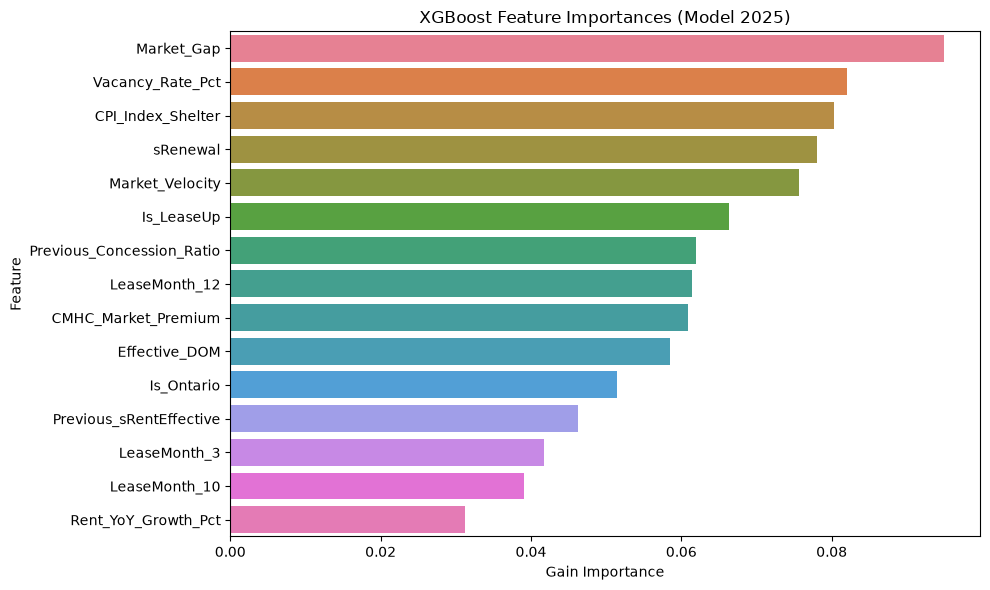


2. SHAP VALUES (XGBoost)


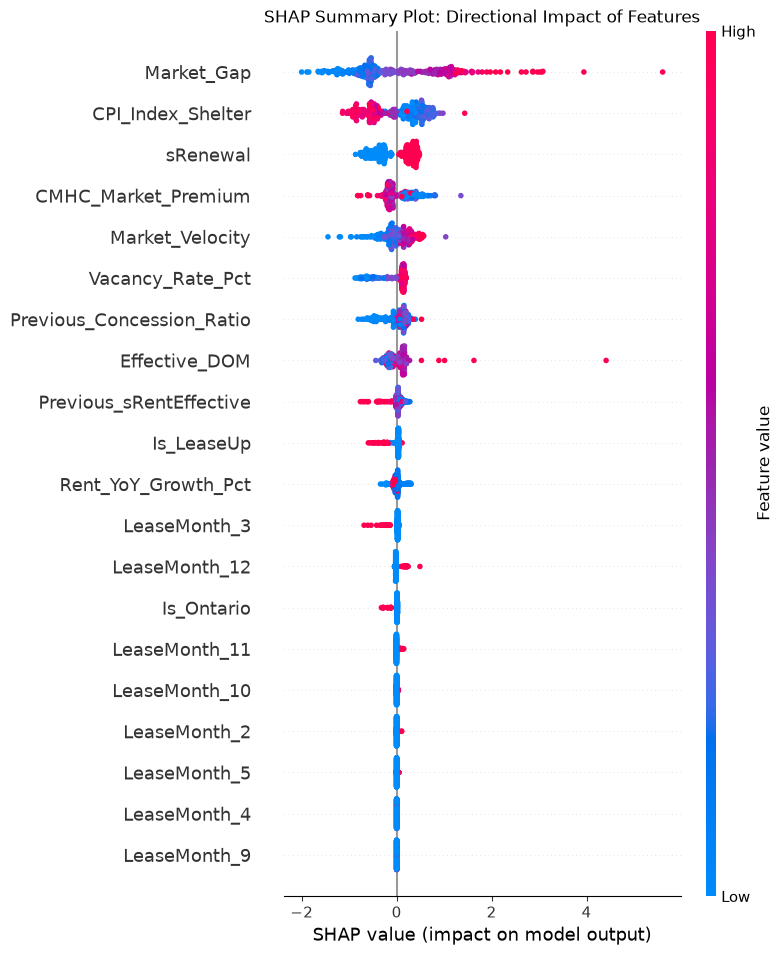


3. PARTIAL DEPENDENCE PLOTS (Random Forest)


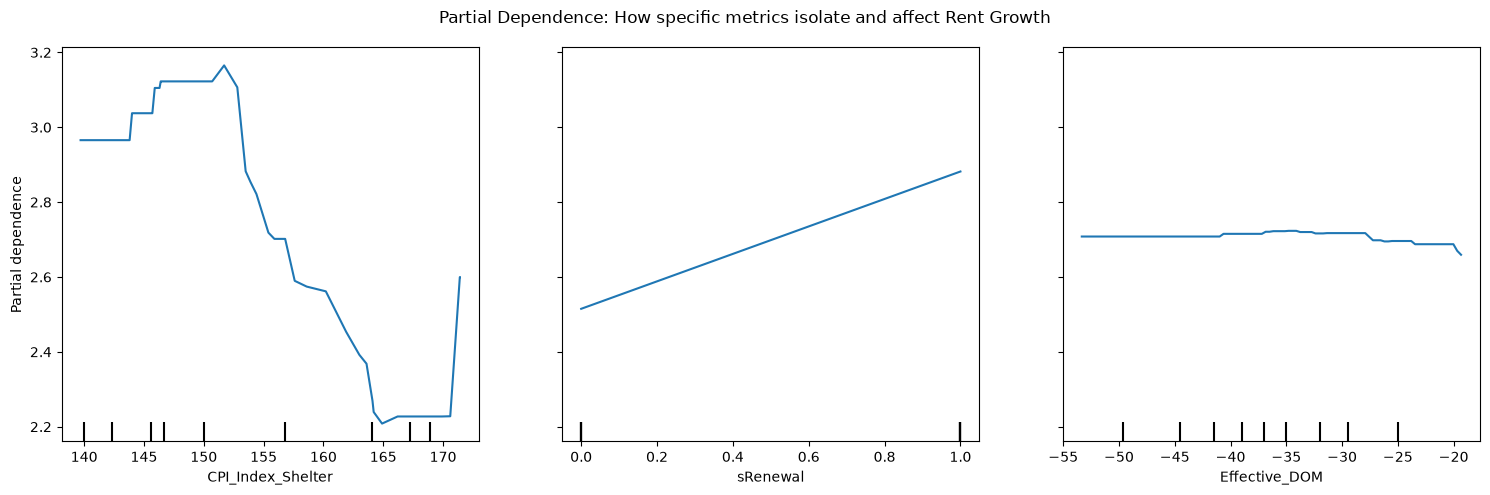

In [136]:
import shap
from sklearn.inspection import PartialDependenceDisplay

last_year = target_years[-1]
final_model = models[last_year]

print("1. FEATURE IMPORTANCE")
imp_df = pd.DataFrame({
    'Feature': X.drop(columns=['Lease_Year']).columns,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, x='Importance', y='Feature', hue='Feature', legend=False)
plt.title(f'XGBoost Feature Importances (Model {last_year})')
plt.xlabel('Gain Importance')
plt.tight_layout()
plt.show()

print("\n2. SHAP VALUES (XGBoost)")
# SHAP shows exactly how much each feature moved the prediction for individual buildings
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_train)
shap.summary_plot(shap_values, X_train, plot_type="dot", show=False)
plt.title('SHAP Summary Plot: Directional Impact of Features')
plt.show()

print("\n3. PARTIAL DEPENDENCE PLOTS (Random Forest)")
# PDPs isolate a feature to show how the model reacts as that feature scales up or down
rf_final = rf_models[last_year]
features_to_plot = ['CPI_Index_Shelter', 'sRenewal', 'Effective_DOM']
fig, ax = plt.subplots(figsize=(15, 5))
PartialDependenceDisplay.from_estimator(rf_final, X_train, features_to_plot, ax=ax)
plt.suptitle('Partial Dependence: How specific metrics isolate and affect Rent Growth')
plt.tight_layout()
plt.show()
